In [1]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
import pickle
import matplotlib as mpl
import seaborn as sb
%load_ext autoreload
%autoreload 2

### First, loading in static data

In [11]:
import json

path = "info\\evaluation_results.json"
with open(path, 'r') as f:
    results = json.load(f)

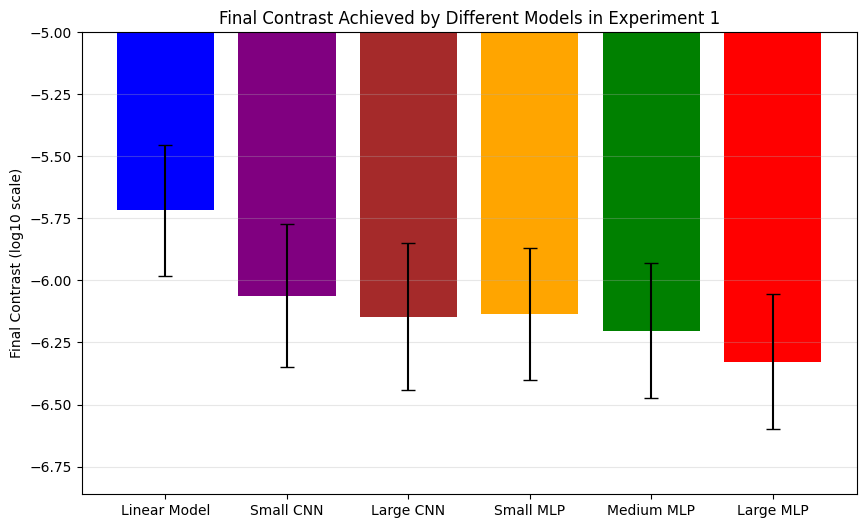

In [12]:
TEXT_COLOR = 'black'

mpl.rcParams['text.color'] = TEXT_COLOR
mpl.rcParams['axes.labelcolor'] = TEXT_COLOR # For axis labels
mpl.rcParams['xtick.color'] = TEXT_COLOR    # For x-axis tick labels
mpl.rcParams['ytick.color'] = TEXT_COLOR    # For y-axis tick labels

experiment1 = results['Experiment 1']

linear_model_fc = experiment1['linear model 2']['final contrast']
small_mlp_fc = experiment1['small mlp']['final contrast']
medium_mlp_fc = experiment1['medium mlp']['final contrast']
large_mlp_fc = experiment1['large mlp']['final contrast']
small_cnn_fc = experiment1['small cnn']['final contrast']
large_cnn_fc = experiment1['large cnn']['final contrast']

linear_model_fc_std = experiment1['linear model 2']['final contrast std']
small_mlp_fc_std = experiment1['small mlp']['final contrast std']
medium_mlp_fc_std = experiment1['medium mlp']['final contrast std']
large_mlp_fc_std = experiment1['large mlp']['final contrast std']
small_cnn_fc_std = experiment1['small cnn']['final contrast std']
large_cnn_fc_std = experiment1['large cnn']['final contrast std']

plt.figure(figsize=(10,6))

plt.grid(axis='y', alpha=0.3)
plt.bar(['Linear Model', 'Small CNN', 'Large CNN', 'Small MLP', 'Medium MLP', 'Large MLP'],
        [linear_model_fc, small_cnn_fc, large_cnn_fc, small_mlp_fc, medium_mlp_fc, large_mlp_fc],
        yerr=[linear_model_fc_std, small_cnn_fc_std, large_cnn_fc_std, small_mlp_fc_std, medium_mlp_fc_std, large_mlp_fc_std],
        capsize=5,
        color=['blue', 'purple', 'brown', 'orange', 'green', 'red'],
        ecolor=TEXT_COLOR)
plt.ylabel('Final Contrast (log10 scale)')      
plt.ylim(max(linear_model_fc, small_mlp_fc, medium_mlp_fc, large_mlp_fc, small_cnn_fc, large_cnn_fc) * 1.2, -5)
plt.title('Final Contrast Achieved by Different Models in Experiment 1')
plt.savefig('images/final_contrast_experiment1.png', transparent=True)
plt.show()


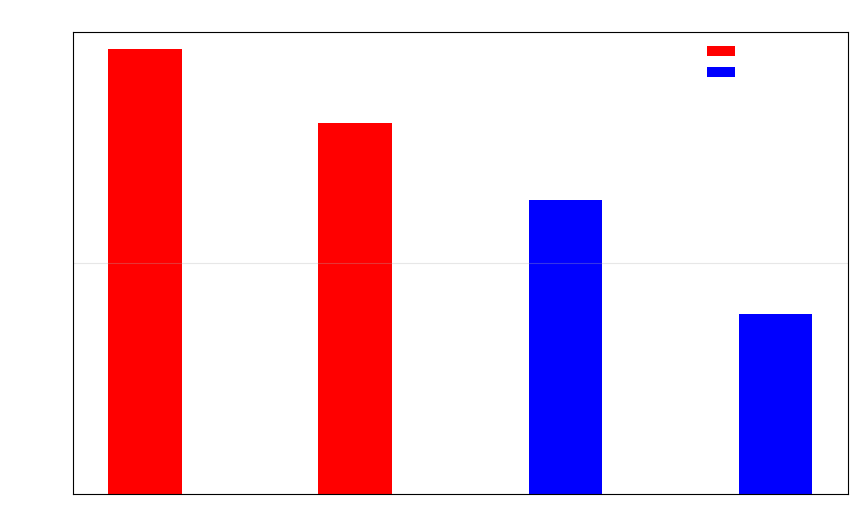

In [41]:
unbiased_large_contrast_prev = experiment1['large mlp']['null image contrast prev']
unbiased_large_contrast_post = experiment1['large mlp']['null image contrast post']
unbiased_linear_contrast_prev = experiment1['linear model']['null image contrast prev']
unbiased_linear_contrast_post = experiment1['linear model']['null image contrast post']

plt.figure(figsize=(10,6))
plt.grid(axis='y', alpha=0.3)
bar_width = 0.35
plt.bar(['Large MLP - Pre', 'Large MLP - Post'],
        [unbiased_large_contrast_prev, unbiased_large_contrast_post],
        width=bar_width,
        color='red',
        label='Large MLP')
plt.bar(['Linear Model - Pre', 'Linear Model - Post'],
        [unbiased_linear_contrast_prev, unbiased_linear_contrast_post],
        width=bar_width,
        color='blue',
        label='Linear Model')
plt.legend(framealpha=0.0)
plt.ylabel('Null Image Contrast (log10 scale)')
plt.yscale('log')
plt.ylim(1e-9, 1e-7)
plt.title('Null Image Contrast Before and After Correction')
plt.savefig('images/null_image_contrast_experiment1.png', transparent=True)
plt.show()

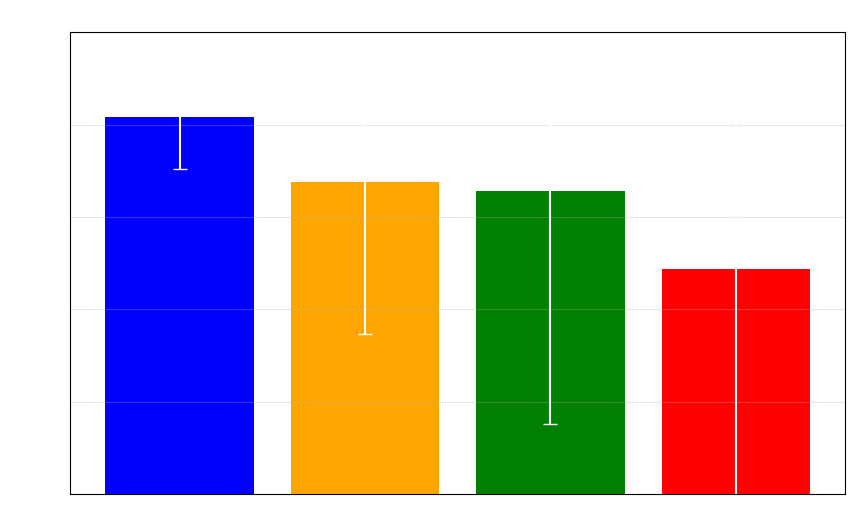

In [5]:
linear_model_cosine = experiment1['linear model']['cosine similarity']
small_mlp_cosine = experiment1['small mlp']['cosine similarity']
medium_mlp_cosine = experiment1['medium mlp']['cosine similarity']
large_mlp_cosine = experiment1['large mlp']['cosine similarity']
linear_model_cosine_std = experiment1['linear model']['cosine similarity std']
small_mlp_cosine_std = experiment1['small mlp']['cosine similarity std']
medium_mlp_cosine_std = experiment1['medium mlp']['cosine similarity std']
large_mlp_cosine_std = experiment1['large mlp']['cosine similarity std']
plt.figure(figsize=(10,6))
plt.grid(axis='y', alpha=0.3)
plt.bar(['Linear Model', 'Small MLP', 'Medium MLP', 'Large MLP'],
        [linear_model_cosine, small_mlp_cosine, medium_mlp_cosine, large_mlp_cosine],
        yerr=[linear_model_cosine_std, small_mlp_cosine_std, medium_mlp_cosine_std, large_mlp_cosine_std],
        capsize=5,
        color=['blue', 'orange', 'green', 'red'],
        ecolor=TEXT_COLOR)
plt.ylabel('Cosine Similarity')
plt.ylim(0.95, 1)
plt.title('Cosine Similarity Achieved by Different Models in Experiment 1')
plt.savefig('images/cosine_similarity_experiment1.png', transparent=True)
plt.show()

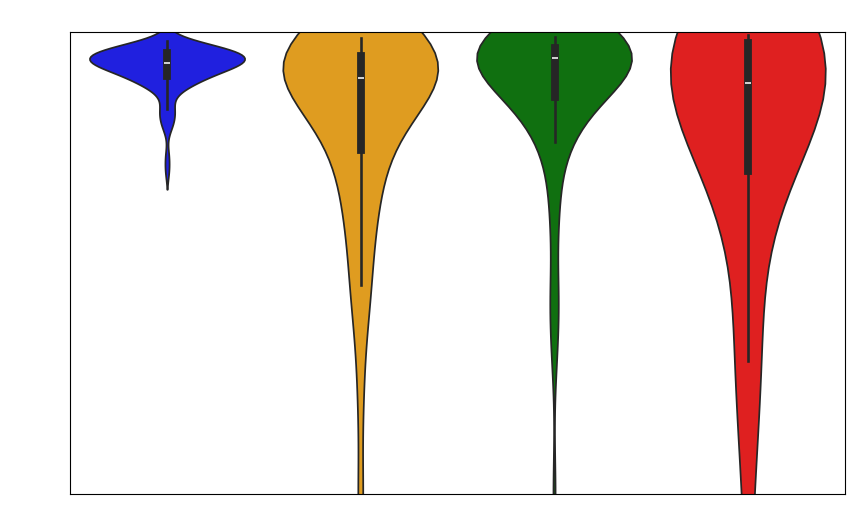

In [7]:
lin_path = "evals\\baseline_evals\\eval_linear model.pkl"
sm_path = "evals\\baseline_evals\\eval_small mlp.pkl"
mm_path = "evals\\baseline_evals\\eval_medium mlp.pkl"
lm_path = "evals\\baseline_evals\\eval_large mlp.pkl"

with open(lin_path, 'rb') as f:
    lin_data = pickle.load(f)
with open(sm_path, 'rb') as f:
    sm_data = pickle.load(f)
with open(mm_path, 'rb') as f:
    mm_data = pickle.load(f)
with open(lm_path, 'rb') as f:
    lm_data = pickle.load(f)

lin_cosine_raw = lin_data['cos_similarities_raw']
sm_cosine_raw = sm_data['cos_similarities_raw']
mm_cosine_raw = mm_data['cos_similarities_raw']
lm_cosine_raw = lm_data['cos_similarities_raw']
plt.figure(figsize=(10,6))
sb.violinplot(data=[lin_cosine_raw, sm_cosine_raw, mm_cosine_raw, lm_cosine_raw],
              palette=['blue', 'orange', 'green', 'red'])
plt.xticks([0,1,2,3], ['Linear Model', 'Small MLP', 'Medium MLP', 'Large MLP'])
plt.ylabel('Cosine Similarity')
plt.ylim(0.90, 1)
plt.title('Cosine Similarity Distribution by Different Models in Experiment 1')
plt.savefig('images/cosine_similarity_distribution_experiment1.png', transparent=True)
plt.show()

In [6]:
eval_dir = 'evals/baseline_evals'
pkl_files = [f for f in os.listdir(eval_dir) if f.endswith('.pkl')]

# fig, axes = plt.subplots(nrows = len(pkl_files), ncols=1, figsize=(8, 6 * len(pkl_files)))

model_stats = {}

colors = ["red", "blue", "orange", "green", "purple", "brown"]

for pkl_file in pkl_files:
    with open(os.path.join(eval_dir, pkl_file), 'rb') as f:
        eval_data = pickle.load(f)

    model_name = pkl_file.replace('.pkl', '')[5:]
    print(f'Evaluating model: {model_name}')

    model_stats[model_name] = {**eval_data}
    # # Example visualization: Plotting the reward over episodes
    # final_contrasts = eval_data['final_contrasts']
    # final_contrasts_std = eval_data['final_contrasts_std']
    # initial_contrasts = eval_data['initial_contrasts']
    # noise_levels = eval_data['noise_levels']
    # cos_similarities = eval_data['cos_similarities']
    # cos_similarities_std = eval_data['cos_similarities_std']

    # predictions = eval_data['predictions']
    # truths = eval_data['truths']
    # model_stats[model_name] = {
    #     'final_contrasts': final_contrasts,
    #     'initial_contrasts': initial_contrasts,
    #     'noise_levels': noise_levels,
    #     'cos_similarities': cos_similarities,
    #     'predictions': predictions,
    #     'truths': truths
    # }

    # differences = final_contrasts - initial_contrasts

    # print(differences.shape)

    

    # plt.scatter(noise_levels, final_contrasts, label=f'{model_name} Final Contrasts', alpha=0.7, color=colors[pkl_files.index(pkl_file) % len(colors)])
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.title('Final Contrasts vs Initial Contrasts')
    # plt.xlabel('Noise Level')
    # plt.ylabel('Final Contrast')



    # ax = axes[pkl_files.index(pkl_file)]
    # ax.set_title(f'Final Contrasts {model_name}')
    # ax.set_xlabel('Initial Contrast')
    # ax.set_ylabel('Final Contrast')
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # differences = final_contrasts - initial_contrasts

    # ax.scatter(noise_levels, final_contrasts, c=-differences, cmap='RdYlGn', alpha=0.7)
# plt.axhline(y=3.88e-08, color="black", linestyle="--", label="Min Contrast for Sim")
# plt.axvline(x=2e-6, color="red", linestyle="--", label="1e-7 Noise Level Training")
# plt.legend()    

# plt.show()

Evaluating model: large mlp
Evaluating model: linear model
Evaluating model: medium mlp
Evaluating model: small mlp


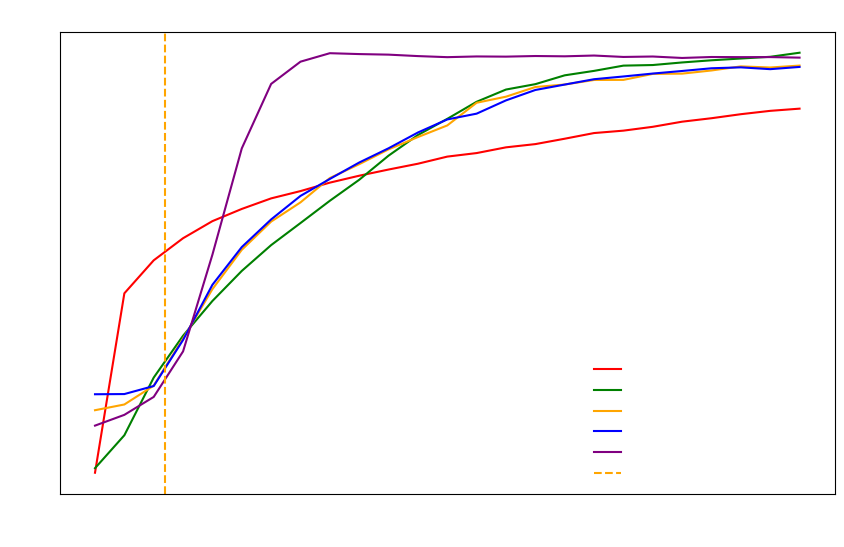

In [30]:
initial_contrasts = model_stats['linear model']['initial_contrasts']
initial_contrasts_std = model_stats['linear model']['initial_contrasts_std']
final_contrasts = model_stats['linear model']['final_contrasts']
final_contrasts_std = model_stats['linear model']['final_contrasts_std']
noise_levels = model_stats['linear model']['noise_levels']
final_contrasts_sm = model_stats['small mlp']['final_contrasts']
final_contrasts_std_sm = model_stats['small mlp']['final_contrasts_std']
noise_levels_sm = model_stats['small mlp']['noise_levels']
final_contrats_mm = model_stats['medium mlp']['final_contrasts']
final_contrasts_std_mm = model_stats['medium mlp']['final_contrasts_std']
noise_levels_mm = model_stats['medium mlp']['noise_levels']
final_contrasts_lm = model_stats['large mlp']['final_contrasts']
final_contrasts_std_lm = model_stats['large mlp']['final_contrasts_std']
noise_levels_lm = model_stats['large mlp']['noise_levels']
initial_contrasts_sm = model_stats['small mlp']['initial_contrasts']


plt.figure(figsize=(10,6))
plt.plot(noise_levels, initial_contrasts, label='Initial Contrast', color="red")
plt.plot(noise_levels, final_contrasts, label='Linear Model Final Contrast', color="green")
plt.plot(noise_levels_sm, final_contrasts_sm, label='Small MLP Final Contrast', color="orange")
plt.plot(noise_levels_mm, final_contrats_mm, label='Medium MLP Final Contrast', color="blue")
plt.plot(noise_levels_lm, final_contrasts_lm, label='Large MLP Final Contrast', color="purple")
# plt.fill_between(noise_levels, final_contrasts - final_contrasts_std, final_contrasts + final_contrasts_std, alpha=0.3, color="green")
# plt.fill_between(noise_levels, initial_contrasts - initial_contrasts_std, initial_contrasts + initial_contrasts_std, alpha=0.3, color="red")
# plt.fill_between(noise_levels_sm, final_contrasts_sm - final_contrasts_std_sm, final_contrasts_sm + final_contrasts_std_sm, alpha=0.3, color="orange", label="Small MLP Final Contrast")
# plt.fill_between(noise_levels_mm, final_contrats_mm - final_contrasts_std_mm, final_contrats_mm + final_contrasts_std_mm, alpha=0.3, color="blue", label="Medium MLP Final Contrast")
# plt.fill_between(noise_levels_lm, final_contrasts_lm - final_contrasts_std_lm, final_contrasts_lm + final_contrasts_std_lm, alpha=0.3, color="purple", label="Large MLP Final Contrast")
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast (log scale)')
plt.title('Final Contrast vs Noise Level')
plt.axvline(x=1e-7, color="orange", linestyle="--", label="1e-7 Noise Level Training")
plt.legend(framealpha=0.0)
plt.savefig('images/final_contrast_vs_noise_linear_model.png', transparent=True)
plt.show()

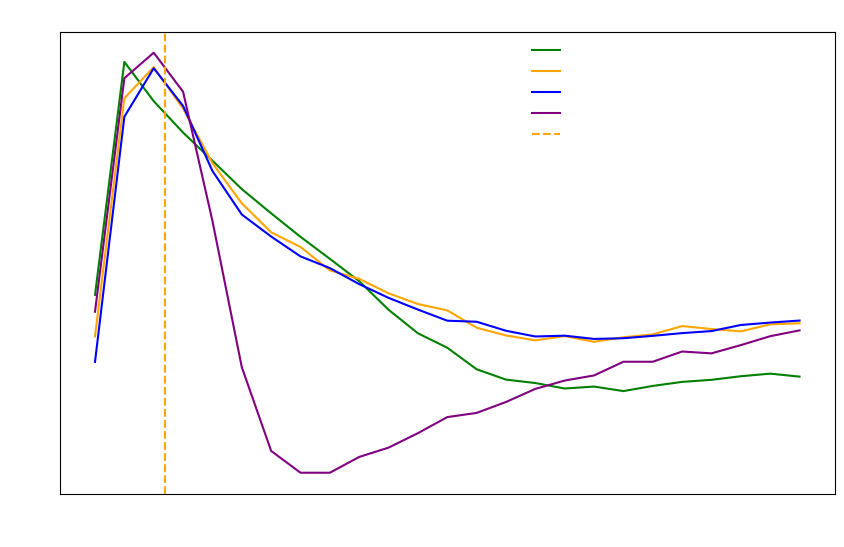

In [22]:
linear_model_contrast_improvements = model_stats['linear model']['initial_contrasts'] - model_stats['linear model']['final_contrasts']
small_mlp_contrast_improvements = model_stats['small mlp']['initial_contrasts'] - model_stats['small mlp']['final_contrasts']
medium_mlp_contrast_improvements = model_stats['medium mlp']['initial_contrasts'] - model_stats['medium mlp']['final_contrasts']
large_mlp_contrast_improvements = model_stats['large mlp']['initial_contrasts'] - model_stats['large mlp']['final_contrasts']
noise_levels = model_stats['linear model']['noise_levels']

# linear_model_contrast_improvements /= -model_stats['linear model']['initial_contrasts']
# small_mlp_contrast_improvements /= -model_stats['small mlp']['initial_contrasts']
# medium_mlp_contrast_improvements /= -model_stats['medium mlp']['initial_contrasts']
# large_mlp_contrast_improvements /= -model_stats['large mlp']['initial_contrasts']

plt.figure(figsize=(10,6))
plt.plot(noise_levels, linear_model_contrast_improvements, label='Linear Model Contrast Improvement', color="green")
plt.plot(noise_levels, small_mlp_contrast_improvements, label='Small MLP Contrast Improvement', color="orange")
plt.plot(noise_levels, medium_mlp_contrast_improvements, label='Medium MLP Contrast Improvement', color="blue")
plt.plot(noise_levels, large_mlp_contrast_improvements, label='Large MLP Contrast Improvement', color="purple")
plt.xlabel('Noise Level')
plt.ylabel('Contrast Improvement')
plt.title('Contrast Improvement vs Noise Level')
plt.axvline(x=1e-7, color="orange", linestyle="--", label="1e-7 Noise Level Training")  
plt.legend(framealpha=0.0)
plt.savefig('images/contrast_improvement_vs_noise_linear_model.png', transparent=True)
plt.show()

In [28]:
eval_dir = 'evals/unbiased_evals'
pkl_files = [f for f in os.listdir(eval_dir) if f.endswith('.pkl')]

model_stats_unbiased = {}

colors = ["red", "blue", "orange", "green", "purple", "brown"]

for pkl_file in pkl_files:
    with open(os.path.join(eval_dir, pkl_file), 'rb') as f:
        eval_data = pickle.load(f)

    model_name = pkl_file.replace('.pkl', '')[5:]
    print(f'Evaluating model: {model_name}')

    model_stats_unbiased[model_name] = {**eval_data}



Evaluating model: large mlp
Evaluating model: linear model


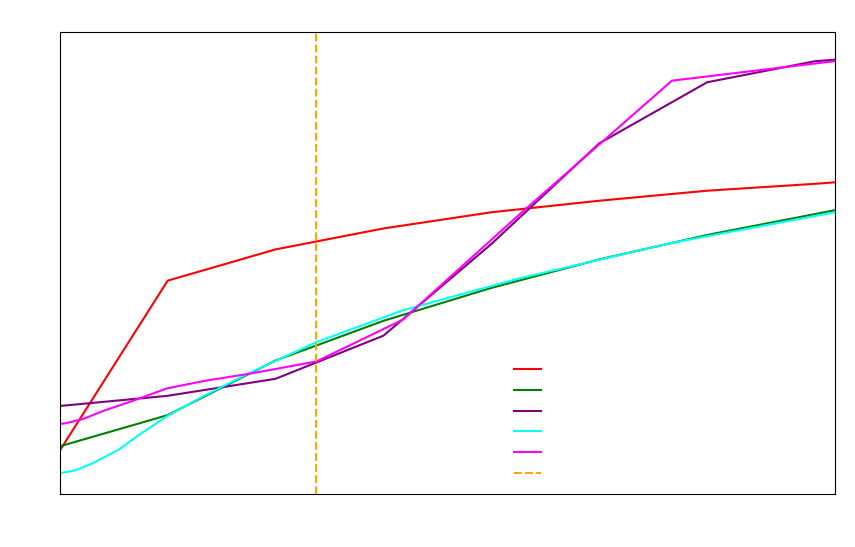

In [48]:
initial_contrasts_unbiased = model_stats_unbiased['linear model']['initial_contrasts']
initial_contrasts_std_unbiased = model_stats_unbiased['linear model']['initial_contrasts_std']
final_contrasts_unbiased = model_stats_unbiased['linear model']['final_contrasts']
final_contrasts_std_unbiased = model_stats_unbiased['linear model']['final_contrasts_std']
noise_levels_unbiased = model_stats_unbiased['linear model']['noise_levels']
final_contrasts_lm_unbiased = model_stats_unbiased['large mlp']['final_contrasts']
final_contrasts_std_lm_unbiased = model_stats_unbiased['large mlp']['final_contrasts_std']
noise_levels_lm_unbiased = model_stats_unbiased['large mlp']['noise_levels']

plt.figure(figsize=(10,6))
plt.plot(noise_levels, initial_contrasts, label='Initial Contrast', color="red")
plt.plot(noise_levels, final_contrasts, label='Linear Model Final Contrast', color="green")
plt.plot(noise_levels_lm, final_contrasts_lm, label='Large MLP Final Contrast', color="purple")
plt.plot(noise_levels_unbiased, final_contrasts_unbiased, label='Linear Model Final Contrast (Unbiased)', color="cyan")
plt.plot(noise_levels_lm_unbiased, final_contrasts_lm_unbiased, label='Large MLP Final Contrast (Unbiased)', color="magenta")
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast (log scale)')
# plt.xscale('log')
plt.title('Final Contrast vs Noise Level (Unbiased Evaluation)')
plt.axvline(x=1e-7, color="orange", linestyle="--", label="1e-7 Noise Level Training")
plt.legend(framealpha=0.0)
plt.xlim(1e-9, 3e-7)
plt.savefig('images/final_contrast_vs_noise_linear_model_unbiased.png', transparent=True)
plt.show()


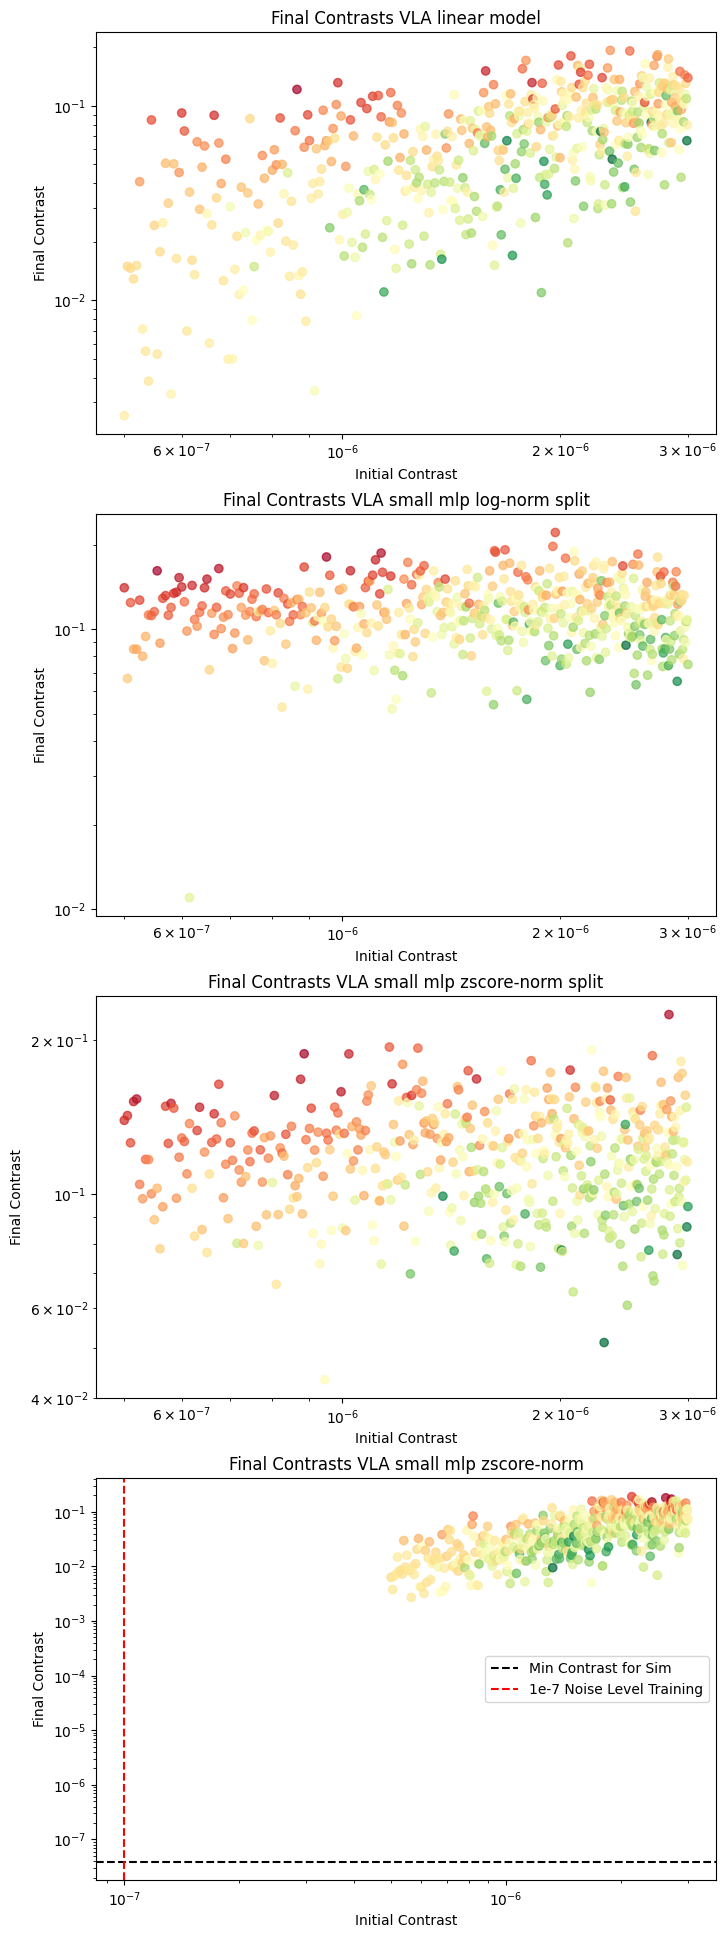

In [87]:
fig, axes = plt.subplots(nrows = len(pkl_files), ncols=1, figsize=(8, 6 * len(pkl_files)))

colors = ["red", "blue", "orange", "green", "purple", "brown"]

for i, (model_name, data) in enumerate(model_stats.items()):
    (final_contrasts, initial_contrasts, noise_levels, cos_similarities, predictions, truths) = data.values()
    
    differences = final_contrasts - initial_contrasts
    mean_improvement = np.mean(differences)
    max_improvement = np.max(differences)
    avg_cosine_similarity = np.mean(cos_similarities)

    
    ax = axes[i]
    ax.set_title(f'Final Contrasts {model_name}')
    ax.set_xlabel('Initial Contrast')
    ax.set_ylabel('Final Contrast')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.scatter(noise_levels, final_contrasts, c=-differences, cmap='RdYlGn', alpha=0.7)

plt.axhline(y=3.88e-08, color="black", linestyle="--", label="Min Contrast for Sim")
plt.axvline(x=1e-7, color="red", linestyle="--", label="1e-7 Noise Level Training")
plt.legend()    
plt.show()

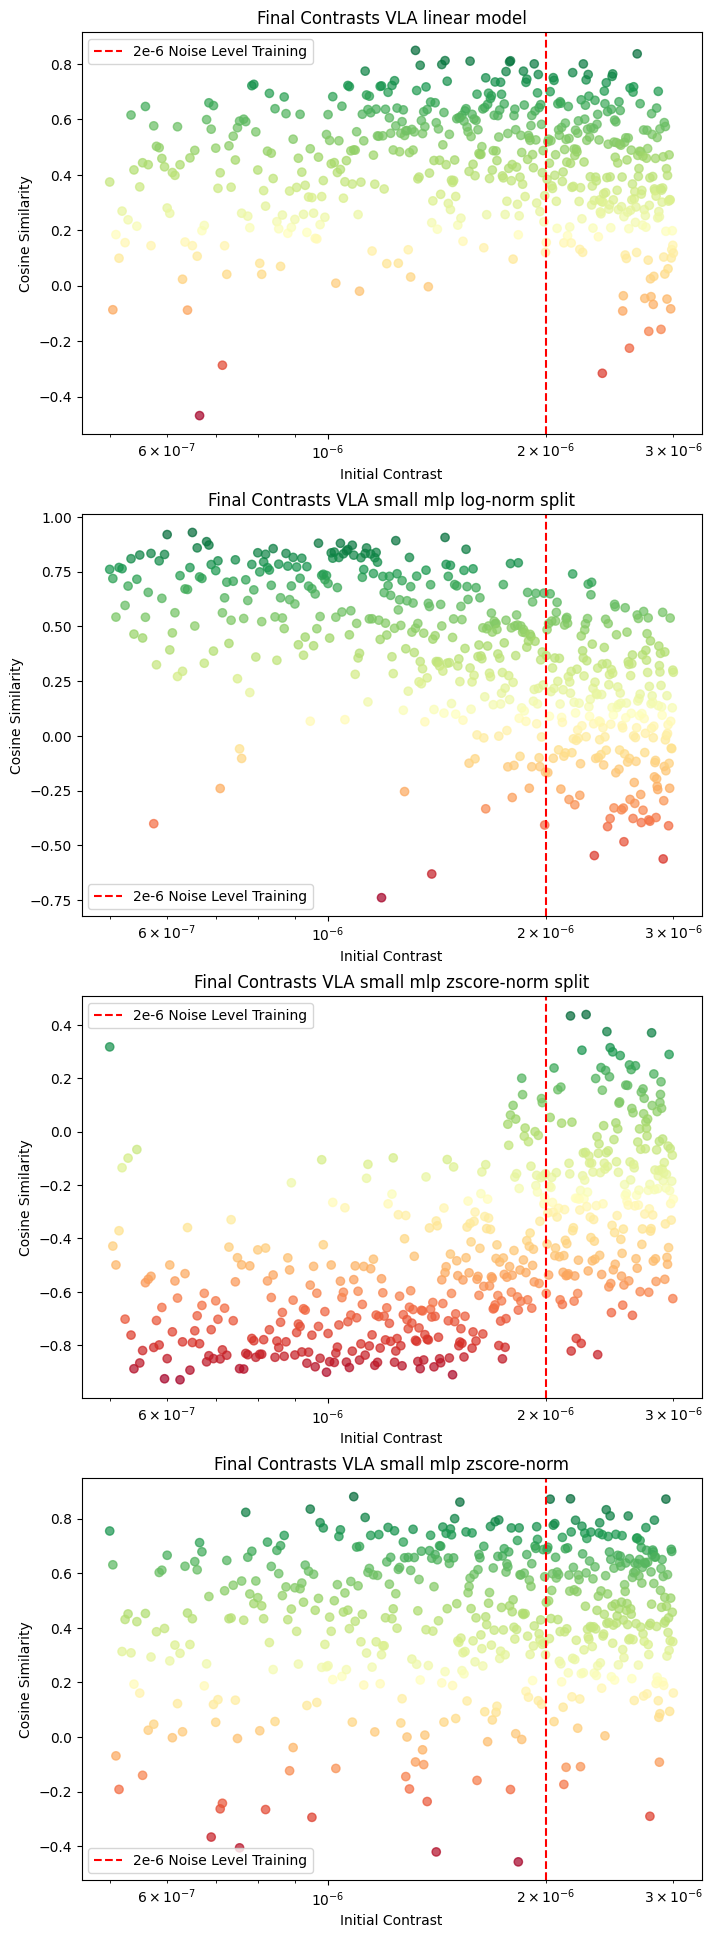

In [88]:
fig, axes = plt.subplots(nrows = len(pkl_files), ncols=1, figsize=(8, 6 * len(pkl_files)))

colors = ["red", "blue", "orange", "green", "purple", "brown"]

for i, (model_name, data) in enumerate(model_stats.items()):
    (final_contrasts, initial_contrasts, noise_levels, cos_similarities, predictions, truths) = data.values()
    
    differences = final_contrasts - initial_contrasts
    mean_improvement = np.mean(differences)
    max_improvement = np.max(differences)
    avg_cosine_similarity = np.mean(cos_similarities)

    
    ax = axes[i]
    ax.set_title(f'Final Contrasts {model_name}')
    ax.set_xlabel('Initial Contrast')
    ax.set_ylabel('Cosine Similarity')
    ax.set_xscale('log')
    ax.scatter(noise_levels, cos_similarities, c=cos_similarities, cmap='RdYlGn', alpha=0.7)
    ax.axvline(x=2e-6, color="red", linestyle="--", label="2e-6 Noise Level Training")
    ax.legend()

  
plt.show()